# NBA ⭐USG -> WIN% - 2025-2026




#**Summary of Findings**
##**Introduction**
The dataset I chose to analyze (NBA Dataset: Box Scores and Stats (1947 - Today) on kaggle) consists of NBA team and player statistics, providing information such as team win-loss records, player minutes played, points scored, field goal attempts, free throw attempts, turnovers, and various advanced metrics. The purpose of collecting and analyzing this data is to understand the relationship between star player usage rate (USG%) and team success, as measured by winning percentage. The central question I am wondering is: Does a star player's usage rate independently predict team winning percentage, or is this relationship confounded by overall team quality?

This study uses the 2025-2026 NBA Season as a refernce for these stats.

I calculated usage rate using the standard formula from Basketball Reference         
(https://www.basketball-reference.com/about/glossary.html#fga):

USG% = 100 * ((FGA + 0.44 * FTA + TOV) * (Team Minutes / 5)) / (Minutes * (Team FGA + 0.44 * Team FTA + Team TOV))

For each team, I identified the player with the highest usage rate who also met some minimum criteria (at least 20 games played and 25 minutes per game). I then examined the correlation between these star players' usage rates and their teams' winning percentages, while also accounting for team quality using net rating as a confounding variable.
<br><br>
##**Cleaning and EDA**
In order to complete this analysis, I first needed to isolate the 2025-2026 NBA regular season data from the comprehensive dataset. The TeamStatistics.csv file contained data from 1947 to the present, so I filtered for the 2025-2026 season and regular season games only. I then calculated each team's win count and winning percentage by grouping by team and summing wins.

For player statistics, I similarly filtered the PlayerStatistics.csv file for the 2025-2026 regular season. I calculated per-game averages for each player across key statistical categories including minutes, points, assists, rebounds, field goal attempts, free throw attempts, and turnovers.

To compute usage rate, I merged player game-level data with team-level statistics to obtain team totals for field goal attempts, free throw attempts, turnovers, and total minutes. I then applied the usage rate formula to calculate each player's usage rate for each game, which I then averaged across the season to get each player's average usage rate.
<br><br>
###**SQL Integration**
While I could have done all aggregations in Pandas, I wanted to use SQLite to demonstrate my ability to work with relational databases. I wrote CTEs to calculate team winning percentages, filter qualifying players, and to rank them by usage rate.
<br><br>
###**Key Cleaning Steps:**

Isolating regular season data: I filtered out playoff games and games from other seasons to focus solely on the 2025-2026 regular season.

Identifying star players: For each team, I identified the player with the highest average usage rate who also met minimum thresholds:

At least 20 games played

Average of at least 25 minutes per game

Calculating team winning percentages: I computed each team's win percentage as (wins / games) * 100.

Merging datasets: I merged the star player usage rate data with team win percentages and net ratings from an external source (Basketball Reference).
<br><br>
###**Univariate Analysis:**

Team winning percentages ranged from 20.73% (Washington Wizards) to 78.05% (Oklahoma City Thunder).

Star player usage rates ranged from 25.53% (Alex Sarr, Wizards) to 38.43% (Luka Doncic, Lakers).

The distribution of star usage rates showed a relatively normal spread, with most star players in the 27-33% range.
<br><br>
###**Bivariate Analysis:**

I first examined the correlation between star usage rate and team win percentage.

The initial analysis showed a Pearson correlation of 0.408, suggesting that there was a moderate positive relationship.

However, I suspected this relationship might be confounded by overall team quality.
<br><br>
##**Assessment of Confounding**
After identifying the positive correlation between star usage rate and winning percentage, I recognized that team quality (as measured by net rating) could be a confounding variable. Better teams may have better players who naturally command higher usage rates, and these better teams also win more games. Therefore, the observed correlation might not indicate a causal relationship between usage rate and winning.

To assess this, I conducted a multiple regression analysis where I predicted team winning percentage using both star usage rate and net rating as predictors. This allowed us to examine whether usage rate independently predicted winning after accounting for team quality.
<br><br>
###**Results of Multiple Regression:**

Net rating was a strong and statistically significant predictor of winning percentage (p < 0.001).

Star usage rate was NOT a statistically significant predictor of winning percentage after controlling for net rating (p = 0.089).

The R-squared of the model was 0.942, indicating that net rating and usage rate together explain 94.2% of the variance in winning percentage.
<br><br>
###**Interpretation:**
The fact that net rating dominates the prediction suggests that team quality is the primary driver of both high usage rates and winning. Star players on good teams will usually tend to have high usage rates, and that will cause their team to win games. But the usage rate itself doesn't appear to independently contribute to wins. This is a classic case of confounding: good teams make players look good, rather than high usage players making teams good.
<br><br>
##**Conclusion**
The analysis reveals that while there is a moderate positive correlation between star player usage rate and team winning percentage, this relationship is largely driven by team quality, or as judged net rating, rather than the usage rate itself. After accounting for team quality, star usage rate no longer independently predicts winning.

This finding provides several important insights:

Correlation ≠ Causation: The initial positive correlation between usage rate and winning is confounded by team quality.

Team Quality Matters Most: Net rating is the dominant predictor of winning, suggesting that overall team performance drives success more than any single player's usage.

Star Players Benefit from Good Teams: High usage rates among star players are more likely a result of being on good teams with effective systems and quality teammates, rather than being a driver of success.
<br><br>
###**Limitations:**

The "star player" definition (highest usage rate among qualified players) may not capture all franchise cornerstones.

Net rating itself is a team-level statistic that may not encompass other important key factors.




---

#**Code**
##**Data Loading and Initial Setup**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sqlite3
conn = sqlite3.connect('nba_analytics.db')

Mounted at /content/drive


##**Data Cleaning and EDA**
###**Team Statistics**

In [2]:
# load the team statistics
path = '/content/drive/MyDrive/Datasets/TeamStatistics.csv'
team_stats = pd.read_csv(path, low_memory=False)


# converting gameDate to datetime and defining season function
team_stats['gameDate'] = pd.to_datetime(team_stats['gameDate'])

def get_nba_season(date):
    year = date.year
    month = date.month
    if month < 10:  # Jan to Sep
        return f"{year-1}-{year}"
    else:           # Oct to Dec
        return f"{year}-{year+1}"

team_stats['Season'] = team_stats['gameDate'].apply(get_nba_season)

team_stats.to_sql('team_stats', conn, if_exists='replace', index=False)
# calculate team win percentages
sql_team_wins = """
SELECT
    teamCity,
    teamName,
    COUNT(gameId) AS games,
    SUM(win) AS wins,
    ROUND( (SUM(win) * 1.0 / COUNT(gameId)) * 100, 2) AS win_pct
FROM team_stats
WHERE Season = '2025-2026'
  AND gameType = 'Regular Season'
GROUP BY teamCity, teamName
ORDER BY win_pct DESC;
"""

# load sql results into dataframe and format results
final_table_2026 = pd.read_sql_query(sql_team_wins, conn)
final_table_2026['win_pct_display'] = final_table_2026['win_pct'].astype(str) + '%'
final_table_2026['2025-2026 NBA Team'] = final_table_2026['teamCity'] + ' ' + final_table_2026['teamName']

display(final_table_2026[['2025-2026 NBA Team', 'wins', 'games', 'win_pct_display']])

,2025-2026 NBA Team,wins,games,win_pct_display
0,Oklahoma City Thunder,64.0,82,78.05%
1,San Antonio Spurs,62.0,82,75.61%
2,Detroit Pistons,60.0,82,73.17%
3,Boston Celtics,56.0,82,68.29%
4,Denver Nuggets,54.0,82,65.85%
5,Los Angeles Lakers,53.0,82,64.63%
6,New York Knicks,53.0,82,64.63%
7,Cleveland Cavaliers,52.0,82,63.41%
8,Houston Rockets,52.0,82,63.41%
9,Minnesota Timberwolves,49.0,82,59.76%


###**Player Statistics**

In [3]:
# load the player statistics
path = '/content/drive/MyDrive/Datasets/PlayerStatistics.csv'
player_stats = pd.read_csv(path, low_memory=False)

# convert gameDate to datetime
player_stats['gameDate'] = pd.to_datetime(player_stats['gameDate'])

# apply season function from above cell
player_stats['Season'] = player_stats['gameDate'].apply(get_nba_season)

# filter for 2025-2026 season
mask = (player_stats['Season'] == '2025-2026') & (player_stats['gameType'] == 'Regular Season')
season_stats = player_stats[mask].copy()

stat_columns = [
    'numMinutes', 'points', 'assists', 'blocks', 'steals',
    'fieldGoalsAttempted', 'fieldGoalsMade', 'fieldGoalsPercentage',
    'threePointersAttempted', 'threePointersMade', 'threePointersPercentage',
    'freeThrowsAttempted', 'freeThrowsMade', 'freeThrowsPercentage',
    'reboundsDefensive', 'reboundsOffensive', 'reboundsTotal',
    'foulsPersonal', 'turnovers', 'plusMinusPoints'
]

# filter players with 0 minutes
for col in stat_columns:
    season_stats[col] = pd.to_numeric(season_stats[col], errors='coerce')
season_stats = season_stats[season_stats['numMinutes'] > 0]

season_stats['Player'] = season_stats['firstName'] + ' ' + season_stats['lastName']

# calculate the per game averages of every player
player_averages = season_stats.groupby('Player', as_index=False)[stat_columns].mean()
player_averages = player_averages.rename(columns={col: f'avg_{col}' for col in stat_columns})
avg_columns = [f'avg_{col}' for col in stat_columns]
player_averages[avg_columns] = player_averages[avg_columns].round(2)

player_averages

,Player,avg_numMinutes,avg_points,avg_assists,avg_blocks,avg_steals,avg_fieldGoalsAttempted,avg_fieldGoalsMade,avg_fieldGoalsPercentage,avg_threePointersAttempted,...,avg_threePointersPercentage,avg_freeThrowsAttempted,avg_freeThrowsMade,avg_freeThrowsPercentage,avg_reboundsDefensive,avg_reboundsOffensive,avg_reboundsTotal,avg_foulsPersonal,avg_turnovers,avg_plusMinusPoints
0,A.J. Lawson,9.20,4.21,0.29,0.17,0.50,3.25,1.42,0.26,1.88,...,0.22,0.75,0.58,0.30,1.42,0.38,1.79,1.12,0.25,-0.38
1,AJ Green,28.90,10.37,1.95,0.10,0.50,7.92,3.36,0.41,7.10,...,0.40,0.79,0.68,0.31,2.36,0.37,2.73,2.29,0.96,-1.90
2,AJ Johnson,9.24,3.33,0.98,0.06,0.23,3.67,1.19,0.21,1.19,...,0.11,0.83,0.71,0.21,0.85,0.29,1.15,0.62,0.62,-1.10
3,Aaron Gordon,27.70,16.17,2.67,0.28,0.58,11.06,5.50,0.45,4.36,...,0.34,4.53,3.47,0.71,4.39,1.42,5.81,1.72,1.06,7.56
4,Aaron Holiday,13.53,5.47,1.05,0.09,0.47,4.42,1.84,0.39,2.98,...,0.33,0.72,0.61,0.29,0.79,0.23,1.02,1.26,0.67,2.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,Zach LaVine,31.18,19.18,2.28,0.26,0.72,14.03,6.72,0.47,6.51,...,0.37,3.64,3.21,0.72,2.56,0.21,2.77,2.08,1.90,-7.95
578,Zeke Nnaji,11.83,3.65,0.56,0.46,0.33,2.90,1.37,0.40,1.04,...,0.11,0.85,0.65,0.21,1.98,0.63,2.62,1.37,0.52,-2.10
579,Ziaire Williams,22.66,10.23,1.07,0.38,1.36,7.73,3.29,0.40,4.48,...,0.33,2.50,2.12,0.56,1.86,0.54,2.39,2.07,1.05,-5.04
580,Zion Williamson,29.49,21.00,3.21,0.55,0.97,13.02,7.81,0.60,0.06,...,0.02,7.50,5.37,0.71,3.68,2.02,5.69,2.27,2.03,-1.32


###**Calculating Usage Rate**

In [4]:
# rename for merging and calculate team total minutes per game
season_stats = season_stats.rename(columns={'playerteamName': 'teamName'})
team_minutes = season_stats.groupby(['gameId', 'teamName'], as_index=False)['numMinutes'].sum()
team_minutes.rename(columns={'numMinutes': 'Tm_MP'}, inplace=True)

# team stats
team_stats_season = team_stats[
    (team_stats['Season'] == '2025-2026') &
    (team_stats['gameType'] == 'Regular Season')
].copy()
team_cols = ['gameId', 'teamName', 'fieldGoalsAttempted', 'freeThrowsAttempted', 'turnovers']
team_stats_season = team_stats_season[team_cols]
for col in ['fieldGoalsAttempted', 'freeThrowsAttempted', 'turnovers']:
    team_stats_season[col] = pd.to_numeric(team_stats_season[col], errors='coerce')

# merge player and team data
season_stats_merged = season_stats.merge(
    team_stats_season,
    on=['gameId', 'teamName'],
    how='left',
    suffixes=('', '_team')
)

season_stats_merged = season_stats_merged.merge(
    team_minutes,
    on=['gameId', 'teamName'],
    how='left'
)

# calculations for usage rate
num_cols = ['fieldGoalsAttempted', 'freeThrowsAttempted', 'turnovers', 'numMinutes',
            'fieldGoalsAttempted_team', 'freeThrowsAttempted_team', 'turnovers_team', 'Tm_MP']
for col in num_cols:
    season_stats_merged[col] = pd.to_numeric(season_stats_merged[col], errors='coerce')

denominator = (
    season_stats_merged['numMinutes'] *
    (season_stats_merged['fieldGoalsAttempted_team'] + 0.44 * season_stats_merged['freeThrowsAttempted_team'] + season_stats_merged['turnovers_team'])
)
season_stats_merged['usage_rate'] = np.where(
    denominator != 0,
    100 *
    (season_stats_merged['fieldGoalsAttempted'] + 0.44 * season_stats_merged['freeThrowsAttempted'] + season_stats_merged['turnovers']) *
    (season_stats_merged['Tm_MP'] / 5) / denominator,
    np.nan
)

# calculate average usage rate per player
usage_avg = season_stats_merged.groupby('Player')['usage_rate'].mean().reset_index()
usage_avg.rename(columns={'usage_rate': 'avg_usage_rate'}, inplace=True)

# merge with averages
if usage_avg.empty:
    player_averages['avg_usage_rate'] = np.nan
else:
    player_averages = player_averages.merge(usage_avg, on='Player', how='left')
    player_averages['avg_usage_rate'] = player_averages['avg_usage_rate'].round(2)

display(player_averages[['Player', 'avg_points', 'avg_usage_rate']])

,Player,avg_points,avg_usage_rate
0,A.J. Lawson,4.21,18.22
1,AJ Green,10.37,13.97
2,AJ Johnson,3.33,17.26
3,Aaron Gordon,16.17,22.80
4,Aaron Holiday,5.47,16.38
...,...,...,...
577,Zach LaVine,19.18,23.78
578,Zeke Nnaji,3.65,14.37
579,Ziaire Williams,10.23,18.96
580,Zion Williamson,21.00,25.76


In [5]:
# save the cleaned data to a sqlite database
season_stats_merged.to_sql('player_stats_with_usage', conn, if_exists='replace', index=False)

print("Data successfully written to nba_analytics.db!")

Data successfully written to nba_analytics.db!


###**Identifying Star Players by Team**

In [6]:
# identify star players as well as the team wins
sql_star_players = """
WITH player_season_avg AS (

    SELECT
        Player,
        teamName,
        ROUND(AVG(usage_rate), 2) AS avg_usage_rate,
        COUNT(DISTINCT gameId) AS games_played,
        ROUND(AVG(numMinutes), 2) AS avg_minutes,
        ROUND(AVG(points), 2) AS avg_points
    FROM player_stats_with_usage
    WHERE usage_rate IS NOT NULL
    GROUP BY Player, teamName
),
qualified_players AS (
    -- added some base filters for star players
    SELECT *
    FROM player_season_avg
    WHERE games_played >= 20
      AND avg_minutes >= 25
),
ranked_players AS (
    SELECT
        q.*,
        ROW_NUMBER() OVER (PARTITION BY teamName ORDER BY avg_usage_rate DESC) AS usage_rank
    FROM qualified_players q
),
team_wins_calc AS (

    SELECT
        teamName,
        ROUND( (SUM(win) * 1.0 / COUNT(gameId)) * 100, 2) AS win_pct,
        SUM(win) AS wins,
        COUNT(gameId) AS games
    FROM team_stats
    WHERE Season = '2025-2026' AND gameType = 'Regular Season'
    GROUP BY teamName
)
-- get the star player per team
SELECT
    r.Player,
    r.teamName,
    r.avg_usage_rate,
    r.avg_points,
    r.avg_minutes,
    r.games_played,
    t.wins,
    t.games,
    t.win_pct
FROM ranked_players r
JOIN team_wins_calc t ON r.teamName = t.teamName
WHERE r.usage_rank = 1  -- Only the highest usage star per team
ORDER BY r.avg_usage_rate DESC;
"""

# execute the sql and load
top_usage_players = pd.read_sql_query(sql_star_players, conn)

display(top_usage_players[['Player', 'teamName', 'avg_points', 'avg_minutes', 'avg_usage_rate', 'games_played']])

,Player,teamName,avg_points,avg_minutes,avg_usage_rate,games_played
0,Luka Doncic,Lakers,33.48,35.54,38.43,64
1,Giannis Antetokounmpo,Bucks,27.58,28.69,37.26,36
2,Jaylen Brown,Celtics,28.70,34.21,36.30,71
3,Joel Embiid,76ers,26.87,31.45,34.07,38
4,Kawhi Leonard,Clippers,27.89,31.87,33.92,65
5,Shai Gilgeous-Alexander,Thunder,31.13,33.01,33.48,68
6,Victor Wembanyama,Spurs,25.00,28.93,32.93,64
7,Jalen Green,Suns,17.75,25.67,32.48,32
8,Ja Morant,Grizzlies,19.45,28.20,32.42,20
9,Donovan Mitchell,Cavaliers,27.89,33.25,32.38,70


##**Correlation and Regression Analysis**
###**Initial Correlation Analysis**

Pearson correlation between star usage rate and win%: 0.408


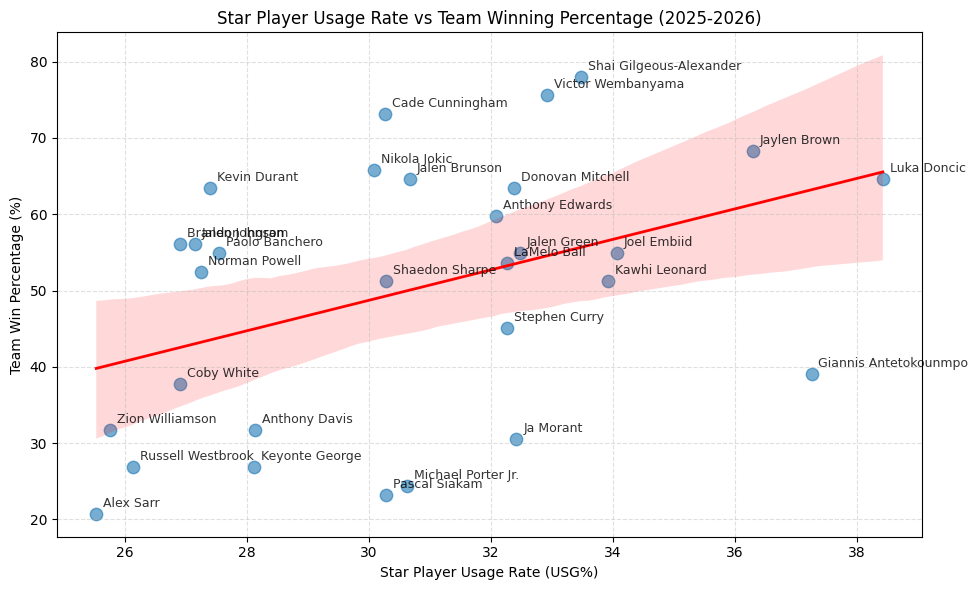

,Player,teamName,avg_usage_rate,wins,games,win_pct
0,Luka Doncic,Lakers,38.43,53.0,82,64.63
1,Giannis Antetokounmpo,Bucks,37.26,32.0,82,39.02
2,Jaylen Brown,Celtics,36.30,56.0,82,68.29
3,Joel Embiid,76ers,34.07,45.0,82,54.88
4,Kawhi Leonard,Clippers,33.92,42.0,82,51.22
5,Shai Gilgeous-Alexander,Thunder,33.48,64.0,82,78.05
6,Victor Wembanyama,Spurs,32.93,62.0,82,75.61
7,Jalen Green,Suns,32.48,45.0,82,54.88
8,Ja Morant,Grizzlies,32.42,25.0,82,30.49
9,Donovan Mitchell,Cavaliers,32.38,52.0,82,63.41


In [7]:
merged = top_usage_players.copy()
merged['win_pct'] = merged['win_pct'].astype(float)

# calculate the correlation
correlation = merged['avg_usage_rate'].corr(merged['win_pct'])
print(f"Pearson correlation between star usage rate and win%: {correlation:.3f}")

# create the visualization
plt.figure(figsize=(10, 6))
sns.regplot(
    data=merged,
    x='avg_usage_rate',
    y='win_pct',
    scatter_kws={'alpha': 0.6, 's': 80},
    line_kws={'color': 'red', 'lw': 2}
)

for i, row in merged.iterrows():
    plt.annotate(
        row['Player'],
        (row['avg_usage_rate'], row['win_pct']),
        textcoords="offset points",
        xytext=(5,5),
        ha='left',
        fontsize=9,
        alpha=0.8
    )

plt.title('Star Player Usage Rate vs Team Winning Percentage (2025-2026)')
plt.xlabel('Star Player Usage Rate (USG%)')
plt.ylabel('Team Win Percentage (%)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

display(merged[['Player', 'teamName', 'avg_usage_rate', 'wins', 'games', 'win_pct']])

###**Multiple Regression with Net Rating**

                            OLS Regression Results                            
Dep. Variable:                win_pct   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     221.3
Date:                Thu, 06 Aug 2026   Prob (F-statistic):           1.80e-17
Time:                        22:28:50   Log-Likelihood:                -84.010
No. Observations:                  30   AIC:                             174.0
Df Residuals:                      27   BIC:                             178.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             37.1714      7.413      5.

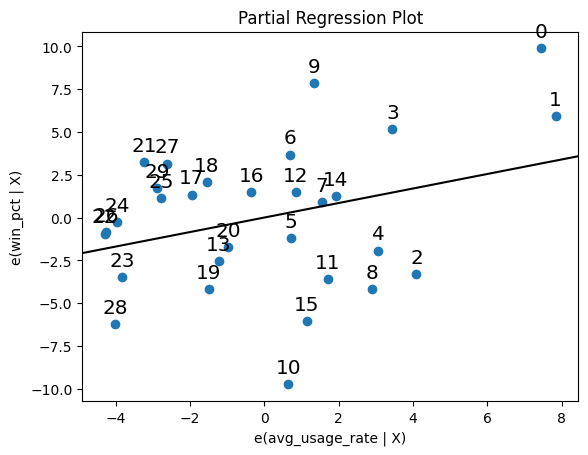

In [8]:
# load team net rating data
net_rating = pd.read_csv('/content/drive/MyDrive/Datasets/NBANetRatings.csv',
                         header=None, names=['full_name', 'short_name', 'net_rating'])

# merge it with the team data
merged_with_net = merged.merge(net_rating[['short_name', 'net_rating']],
                               left_on='teamName', right_on='short_name', how='left')

merged_with_net = merged_with_net.dropna(subset=['net_rating'])

# create the multiple regression
import statsmodels.api as sm
X = merged_with_net[['avg_usage_rate', 'net_rating']]
X = sm.add_constant(X)
y = merged_with_net['win_pct']
model = sm.OLS(y, X).fit()
print(model.summary())

# create the partial regression plot
from statsmodels.graphics.regressionplots import plot_partregress
plot_partregress('win_pct', 'avg_usage_rate', ['net_rating'], data=merged_with_net)
plt.show()

##**Key Findings Summary**
###**Regression Results:**

Model R-squared: 0.942

Net Rating Coefficient: 2.5504 (p < 0.001)

Usage Rate Coefficient: 0.4243 (p = 0.089, which means NOT statistically significant)
<br><br>
###**Interpretation**
The regression results clearly show that after accounting for team quality (net rating), star player usage rate does not significantly predict winning percentage. The coefficient for usage rate is not statistically different from zero (p = 0.089, which is above the conventional threshold of 0.05). This suggests that the initial positive correlation between usage rate and winning is not causal but merely reflects that better teams have better players who naturally have higher usage rates.
<br><br>
###**Practical Implications:**

NBA teams should focus more on building overall team quality rather than maximizing a single player's usage.

Star players on winning teams naturally accumulate high usage rates through effective team systems.

#**Tableau Dashboard**
I built a dashboard that can be viewed here for non-technical understanding. The dashboard explores the relationships between usage and winning as well as the top 10 players by usage rate.
<br><br>
You can find the link here: https://public.tableau.com/app/profile/nathan.nguyen8587/viz/NBAUSG-WIN/Dashboard1

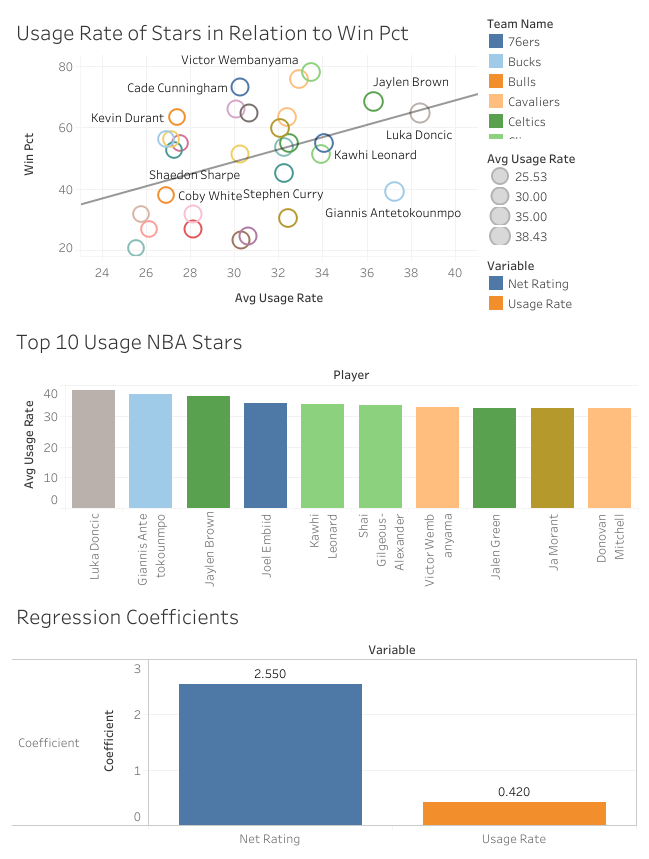